# 05 · Tuning — CatBoost con Optuna

El baseline (`01_modelos_baseline.ipynb`) dejó los modelos parejos dentro del
**techo de señal** del problema (~0.77 AUC), y los notebooks 02–04 tunearon
XGBoost, Random Forest y Regresión Logística. Aquí sumamos **CatBoost** al
torneo, con **exactamente el mismo pipeline y protocolo** que XGBoost, para
responder una pregunta concreta: **¿CatBoost también rinde bien en este
problema, o queda dentro del mismo techo?**

## ¿Por qué CatBoost?

Es un *gradient boosting* de árboles, como XGBoost, pero con dos diferencias de
diseño que lo hacen interesante de contrastar:

- **Árboles simétricos (*oblivious trees*)**: en cada nivel del árbol usa **el
  mismo split (misma feature y mismo umbral) para todos los nodos**. Esto actúa
  como una regularización fuerte y hace el modelo más rápido y menos propenso a
  sobreajustar — atractivo en un problema **acotado por su techo de señal**.
- ***Ordered boosting***: un esquema de permutaciones que reduce el sesgo de
  *prediction shift* (una fuga sutil por la que cada árbol ve, indirectamente, la
  etiqueta de la fila que intenta predecir). En datasets medianos como este suele
  traducirse en mejor generalización sin tuning agresivo.

No es magia: el **techo de señal (~0.77 AUC)** lo acota igual que a los demás. La
pregunta no es si rompe el techo, sino si **lo alcanza con la misma solvencia** y
si aporta algo en **estabilidad temporal** o **lift del decil top** (el criterio
de selección del campeón).

## ¿Qué es Optuna y por qué no un grid search?

Optuna es un framework de optimización de hiperparámetros con dos ideas clave:

- **Búsqueda bayesiana (TPE — *Tree-structured Parzen Estimator*)**: en lugar de
  probar todas las combinaciones de una grilla (caro y ciego) o puntos al azar,
  modela qué regiones del espacio dieron buenos resultados y **muestrea las
  siguientes pruebas hacia donde es más probable mejorar**.
- **Pruning (poda)**: descarta tempranamente las pruebas que pintan mal. Aquí
  reportamos el AUC fold a fold y dejamos que el `MedianPruner` corte una prueba
  si va peor que la mediana histórica a esa altura.

## Qué optimizamos (y qué NO) — validación cruzada anidada (*nested CV*)

Mismo esquema que el resto de notebooks de tuning, para que la comparación sea
directa. Separamos los **tres roles**:

- **Ajustar + seleccionar (bucle interno)**: Optuna optimiza el **AUC
  out-of-fold de GroupKFold por vendedora, calculado SOLO sobre el train-pool**.
  Cada vendedora cae *o* en train *o* en validación dentro de cada fold → no
  premia memorizar identidades.
- **Evaluar (bucle externo)**: el **split OOT** (escenario de producción) queda
  **totalmente aislado del tuning** y se toca **una sola vez** al final → su AUC
  es una estimación honesta, sin sesgo de selección.
- Expectativa realista: el techo de señal acota a todos los modelos a ~0.77. El
  tuning busca **ganancias marginales + estabilidad temporal + regularización
  sana**.

## 0 · Setup, datos y split

Idéntico a los demás notebooks de modelado para que las métricas sean
comparables: mismo CSV de features, mismas columnas ID excluidas, mismo split OOT
(test = últimos 4 meses, GAP = `v` = 6 meses de etiqueta).

> **Coerción defensiva.** El CSV de features tiene, en su versión vigente, una
> celda corrupta en `monto_ult_vs_media` (un valor de texto `'Directo'` colado
> entre números), lo que convierte toda la columna a `object`. CatBoost —igual
> que XGBoost si se reentrenara hoy— no puede convertir ese texto a float. Como
> salvaguarda **convertimos cualquier feature `object` a numérico**
> (`to_numeric(errors="coerce")`): el valor corrupto pasa a `NaN`, que CatBoost
> maneja de forma nativa. Reportamos cuántos valores se coercionaron para dejar
> rastro del problema (ver también la nota de calidad de datos al final).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import optuna
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
from catboost import CatBoostClassifier

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent
df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"], low_memory=False)
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]

# --- Coerción defensiva: features object -> numérico (corruptos -> NaN) ---
coerced = {}
for c in FEATS:
    if df[c].dtype == "object":
        before_na = df[c].isna().sum()
        df[c] = pd.to_numeric(df[c], errors="coerce")
        n_bad = df[c].isna().sum() - before_na
        if n_bad:
            coerced[c] = int(n_bad)
if coerced:
    print(f"[data quality] valores no numéricos coercionados a NaN: {coerced}")
else:
    print("[data quality] sin columnas object entre las features")

X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values
print(f"dataset: {df.shape[0]:,} filas | {len(FEATS)} features | prevalencia churn {y.mean():.3f}")


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)

# --- nested CV: el bucle interno (tuning) vive SOLO en el train-pool ---
# El train-pool coincide con el train del OOT; el bloque OOT (test) queda aislado
# del tuning y se reserva para el bucle externo (evaluación honesta, una sola vez).
Xp = X[train_mask].reset_index(drop=True)
yp = y[train_mask]
gp = groups[train_mask]
print(f"train-pool (tuning) {train_mask.sum():,} | OOT (test, aislado) {test_mask.sum():,}")

[data quality] valores no numéricos coercionados a NaN: {'monto_ult_vs_media': 1}
dataset: 30,356 filas | 68 features | prevalencia churn 0.309
train-pool (tuning) 28,311 | OOT (test, aislado) 803


## 1 · Función objetivo

`objective(trial)` propone un set de hiperparámetros, entrena un CatBoost en cada
fold de `GroupKFold(5)`, acumula las predicciones **out-of-fold** y devuelve el
AUC global. Detalles de diseño (idénticos al notebook de XGBoost):

- **`scale_pos_weight` por fold**: se recalcula como `neg/pos` *dentro del train
  de cada fold*. Así el ajuste al desbalance no usa información de la partición de
  validación (evita una fuga sutil del ratio de clases). Mantenemos el mismo
  mecanismo que XGBoost —en vez de `auto_class_weights`— para que la comparación
  sea 1 a 1.
- **Reporte + pruning fold a fold**: tras cada fold reportamos el AUC parcial; el
  pruner puede abortar la prueba si va por debajo de la mediana histórica.
- **`allow_writing_files=False`**: evita que CatBoost escriba el directorio
  `catboost_info/` en cada fit.

### Espacio de búsqueda

Elegimos 9 hiperparámetros que **espejan** los de XGBoost, adaptados a la
mecánica de CatBoost (árboles simétricos + bootstrap Bernoulli):

| Hiperparámetro | Rango | Análogo XGBoost | Qué controla |
|---|---|---|---|
| `iterations` | 300–1200 | `n_estimators` | nº de árboles (capacidad) |
| `depth` | 3–9 | `max_depth` | profundidad del árbol simétrico (2^depth hojas) |
| `learning_rate` | 5e-3–0.3 (log) | `learning_rate` | cuánto aporta cada árbol |
| `l2_leaf_reg` | 1e-3–10 (log) | `reg_lambda` | regularización L2 de los valores de hoja |
| `random_strength` | 1e-3–10 (log) | `gamma` (aprox.) | ruido en el score de los splits (regulariza) |
| `subsample` | 0.5–1.0 | `subsample` | fracción de filas por árbol (bootstrap Bernoulli) |
| `rsm` | 0.5–1.0 | `colsample_bytree` | fracción de columnas por split |
| `min_data_in_leaf` | 1–20 | `min_child_weight` | mínimo de muestras por hoja |
| `border_count` | 32–255 | — | nº de cortes para binarizar features numéricas |

In [2]:
GKF = GroupKFold(n_splits=5)
gkf_folds = list(GKF.split(Xp, yp, gp))   # folds DENTRO del train-pool (no tocan el OOT)


def build_catboost(params, spw):
    return CatBoostClassifier(
        **params,
        scale_pos_weight=spw,
        loss_function="Logloss",
        eval_metric="AUC",
        bootstrap_type="Bernoulli",   # habilita `subsample`
        random_seed=RANDOM_STATE,
        thread_count=-1,
        verbose=False,
        allow_writing_files=False)


def suggest_params(trial):
    return dict(
        iterations=trial.suggest_int("iterations", 300, 1200, step=50),
        depth=trial.suggest_int("depth", 3, 9),
        learning_rate=trial.suggest_float("learning_rate", 5e-3, 0.3, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        random_strength=trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        rsm=trial.suggest_float("rsm", 0.5, 1.0),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 1, 20),
        border_count=trial.suggest_int("border_count", 32, 255),
    )


def objective(trial):
    params = suggest_params(trial)
    oof = np.zeros(len(yp))
    for fold, (tr, va) in enumerate(gkf_folds):
        spw = (yp[tr] == 0).sum() / (yp[tr] == 1).sum()
        model = build_catboost(params, spw)
        model.fit(Xp.iloc[tr], yp[tr])
        oof[va] = model.predict_proba(Xp.iloc[va])[:, 1]
        # AUC acumulado sobre los folds ya evaluados -> permite poda temprana
        seen = np.concatenate([va_idx for _, va_idx in gkf_folds[:fold + 1]])
        trial.report(roc_auc_score(yp[seen], oof[seen]), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return roc_auc_score(yp, oof)

## 2 · Ejecutar el estudio

- **Sampler `TPESampler(seed=42)`**: búsqueda bayesiana reproducible.
- **Pruner `MedianPruner`**: con 5 trials de calentamiento antes de empezar a
  podar.
- `N_TRIALS = 60`: mismo presupuesto que XGBoost/RF/LogReg, para que la
  comparación sea justa.

> Optuna acumula el estudio en memoria. Si quieres persistirlo entre sesiones,
> pasa `storage="sqlite:///optuna_cat.db"` y `load_if_exists=True` a
> `create_study`.

In [3]:
N_TRIALS = 60

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner,
                            study_name="catboost_churn")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

done = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\ntrials completados: {len(done)} | podados: {len(pruned)}")
print(f"mejor AUC validación interna (GroupKFold sobre train-pool): {study.best_value:.4f}")
print("mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:18s} = {v}")

  0%|          | 0/60 [00:00<?, ?it/s]


trials completados: 60 | podados: 0
mejor AUC validación interna (GroupKFold sobre train-pool): 0.7424
mejores hiperparámetros:
  iterations         = 1050
  depth              = 3
  learning_rate      = 0.01784848406762097
  l2_leaf_reg        = 3.475554880790744
  random_strength    = 0.0193673868449059
  subsample          = 0.791500027226696
  rsm                = 0.7086150829006931
  min_data_in_leaf   = 18
  border_count       = 82


## 3 · Diagnóstico de la búsqueda

Historia de optimización (cómo fue mejorando el mejor valor) e importancia de
hiperparámetros (cuáles movieron más la aguja).

/tmp/ipykernel_133987/4072551696.py:7: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = plot_optimization_history(study)


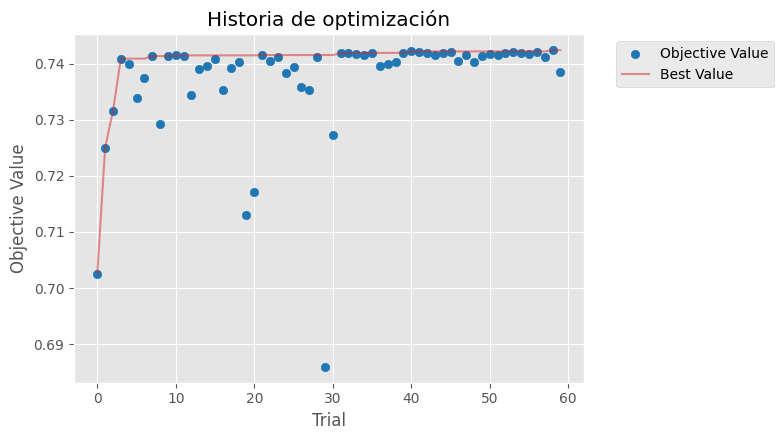

/tmp/ipykernel_133987/4072551696.py:12: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = plot_param_importances(study)


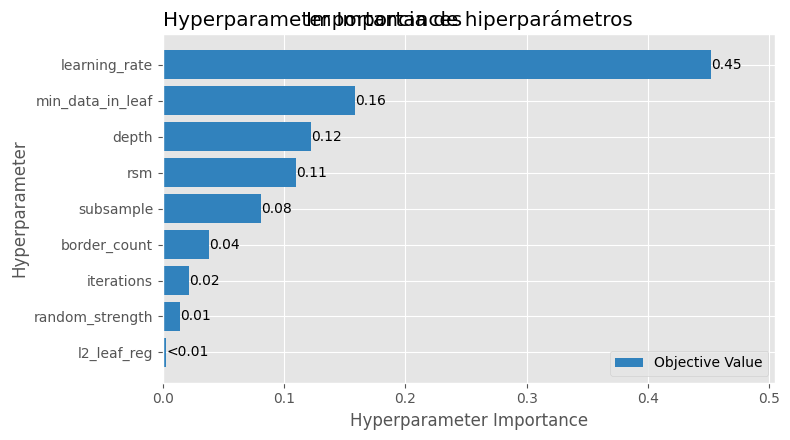

In [4]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (plot_optimization_history,
                                             plot_param_importances)

# Las funciones matplotlib de Optuna crean su propia figura y devuelven el Axes
# (no aceptan ax=). Las llamamos por separado.
ax1 = plot_optimization_history(study)
ax1.set_title("Historia de optimización")
ax1.figure.set_size_inches(8, 4.5)
plt.tight_layout(); plt.show()

ax2 = plot_param_importances(study)
ax2.set_title("Importancia de hiperparámetros")
ax2.figure.set_size_inches(8, 4.5)
plt.tight_layout(); plt.show()

## 4 · Modelo tuneado: evaluación con los dos protocolos

Reconstruimos el CatBoost con los mejores hiperparámetros y lo evaluamos con la
**misma** función que los demás notebooks (GroupKFold sobre el train-pool + OOT
externo). El panel incluye el **lift del decil top** (`oot_lift10`), que es el
criterio con el que se elige el campeón del proyecto.

In [5]:
def top_decile_lift(yt, p):
    k = max(len(yt) // 10, 1)
    sel = np.argsort(-p)[:k]
    return yt[sel].mean() / yt.mean()


def make_tuned_catboost(params):
    spw_train = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()
    return build_catboost(params, spw_train)


def eval_model(params):
    # --- Validación interna: GroupKFold OOF SOBRE EL TRAIN-POOL (bucle interno) ---
    oof = np.zeros(len(yp))
    for tr, va in gkf_folds:
        spw = (yp[tr] == 0).sum() / (yp[tr] == 1).sum()
        m = build_catboost(params, spw)
        m.fit(Xp.iloc[tr], yp[tr])
        oof[va] = m.predict_proba(Xp.iloc[va])[:, 1]
    cv_auc = roc_auc_score(yp, oof); cv_ap = average_precision_score(yp, oof)
    cv_lift = top_decile_lift(yp, oof)
    # --- OOT: bucle externo, test aislado (no visto en el tuning) ---
    model = make_tuned_catboost(params)
    model.fit(X[train_mask], y[train_mask])
    p = model.predict_proba(X[test_mask])[:, 1]; yt = y[test_mask]
    pr = (p >= 0.5).astype(int)
    dft = df[test_mask].copy(); dft["p"] = p
    aucs = [roc_auc_score(g["churn"], g["p"]) for _, g in
            dft.groupby(dft["mes_obs"].dt.strftime("%Y-%m")) if g["churn"].nunique() > 1]
    metrics = {
        "cv_AUC": cv_auc, "cv_PRAUC": cv_ap, "cv_lift10": cv_lift,
        "oot_AUC": roc_auc_score(yt, p), "oot_AUCstd": np.std(aucs),
        "oot_F1": f1_score(yt, pr, zero_division=0),
        "oot_prec": precision_score(yt, pr, zero_division=0),
        "oot_rec": recall_score(yt, pr),
        "oot_lift10": top_decile_lift(yt, p),
    }
    return metrics, model


metrics_tuned, tuned = eval_model(study.best_params)
pd.Series(metrics_tuned).round(4)

cv_AUC        0.7424
cv_PRAUC      0.5329
cv_lift10     1.9989
oot_AUC       0.7652
oot_AUCstd    0.0122
oot_F1        0.5473
oot_prec      0.4286
oot_rec       0.7571
oot_lift10    2.2943
dtype: float64

## 5 · Comparación: CatBoost frente al torneo

La pregunta del notebook es si CatBoost **rinde bien**. Lo ponemos en contexto
contra:

1. **XGBoost baseline** (sin tunear, de `01_modelos_baseline.ipynb`) — para ver la
   ganancia del tuning en OOT.
2. **Los tres modelos ya tuneados** (XGBoost, Random Forest, LogReg) — leyendo el
   `oot_auc` que dejó registrado cada notebook de tuning.

La comparación honesta entre modelos es el **OOT** (test externo). Recuerda que el
**campeón del proyecto se elige por lift del decil top (TDL)**, no solo por AUC:
en el punto operativo t=0.50 se reportan recall y precision, y el TDL mide cuánto
concentra el modelo el churn en el 10% más riesgoso.

In [6]:
# XGBoost baseline (sin tunear), tomado de 01_modelos_baseline.ipynb
baseline_oot = {"oot_AUC": 0.7540, "oot_AUCstd": 0.0160, "oot_F1": 0.5260,
                "oot_prec": 0.4130, "oot_rec": 0.7238, "oot_lift10": 2.2943}
cat_oot = {k: metrics_tuned[k] for k in baseline_oot}
cmp = pd.DataFrame({"XGB baseline": baseline_oot, "CatBoost tuneado": cat_oot}).T
cmp.loc["Δ (Cat − XGBbase)"] = cmp.loc["CatBoost tuneado"] - cmp.loc["XGB baseline"]
print("CatBoost tuneado vs XGBoost baseline — OOT (test externo):")
print(cmp.round(4).to_string())

print(f"\nValidación interna del CatBoost tuneado (GroupKFold sobre train-pool):")
print(f"  AUC {metrics_tuned['cv_AUC']:.4f} | PR-AUC {metrics_tuned['cv_PRAUC']:.4f}"
      f" | lift decil {metrics_tuned['cv_lift10']:.4f}")

CatBoost tuneado vs XGBoost baseline — OOT (test externo):
                   oot_AUC  oot_AUCstd  oot_F1  oot_prec  oot_rec  oot_lift10
XGB baseline        0.7540      0.0160  0.5260    0.4130   0.7238      2.2943
CatBoost tuneado    0.7652      0.0122  0.5473    0.4286   0.7571      2.2943
Δ (Cat − XGBbase)   0.0112     -0.0038  0.0213    0.0156   0.0333     -0.0000

Validación interna del CatBoost tuneado (GroupKFold sobre train-pool):
  AUC 0.7424 | PR-AUC 0.5329 | lift decil 1.9989


In [7]:
# Torneo de modelos TUNEADOS: oot_auc registrado por cada notebook + CatBoost
tuned_files = {
    "XGBoost":      base / "05_modelling" / "xgboost_best_params.json",
    "RandomForest": base / "05_modelling" / "rf_best_params.json",
    "LogReg":       base / "05_modelling" / "logreg_best_params.json",
}
rows = {}
for name, fp in tuned_files.items():
    if fp.exists():
        d = json.load(open(fp))
        rows[name] = {"cv_AUC_trainpool": d.get("best_value_cv_auc_trainpool"),
                      "oot_AUC": d.get("oot_auc")}
rows["CatBoost"] = {"cv_AUC_trainpool": metrics_tuned["cv_AUC"],
                    "oot_AUC": metrics_tuned["oot_AUC"]}
torneo = pd.DataFrame(rows).T.sort_values("oot_AUC", ascending=False)
print("Modelos tuneados — AUC (cada uno con su notebook, N_TRIALS=60):")
print(torneo.round(4).to_string())

pos = list(torneo.index).index("CatBoost") + 1
print(f"\nCatBoost queda #{pos} de {len(torneo)} por AUC OOT "
      f"({torneo.loc['CatBoost','oot_AUC']:.4f}).")
print("Nota: el campeón del proyecto se decide por TDL (lift decil) + recall@0.5, "
      "no solo AUC — ver el panel de la sec. 4 para el TDL de CatBoost.")

Modelos tuneados — AUC (cada uno con su notebook, N_TRIALS=60):
              cv_AUC_trainpool  oot_AUC
LogReg                  0.7394   0.7693
CatBoost                0.7424   0.7652
XGBoost                 0.7422   0.7648
RandomForest            0.7399   0.7590

CatBoost queda #2 de 4 por AUC OOT (0.7652).
Nota: el campeón del proyecto se decide por TDL (lift decil) + recall@0.5, no solo AUC — ver el panel de la sec. 4 para el TDL de CatBoost.


## 6 · Persistir el candidato

Guardamos los mejores hiperparámetros (`catboost_best_params.json`) y el modelo
entrenado sobre el train OOT (`models/catboost_tuned.joblib`), en el mismo formato
que los otros modelos, para que `06_evaluation` pueda cargarlo sin reentrenar si
se decide llevarlo a la comparación final.

In [8]:
import joblib

params_path = base / "05_modelling" / "catboost_best_params.json"
with open(params_path, "w") as f:
    json.dump({"best_params": study.best_params,
               "best_value_cv_auc_trainpool": study.best_value,
               "oot_auc": metrics_tuned["oot_AUC"],
               "n_trials": N_TRIALS, "random_state": RANDOM_STATE}, f, indent=2)
print(f"hiperparámetros → {params_path}")

models_dir = base / "models"; models_dir.mkdir(exist_ok=True)
model_path = models_dir / "catboost_tuned.joblib"
joblib.dump(tuned, model_path)   # `tuned` quedó fit sobre train OOT en la sec. 4
print(f"modelo → {model_path}")

hiperparámetros → /home/carlos/projects/glamour/customer-churn-prediction/05_modelling/catboost_best_params.json
modelo → /home/carlos/projects/glamour/customer-churn-prediction/models/catboost_tuned.joblib


## 7 · Síntesis

**Respuesta a la pregunta del notebook: sí, CatBoost rinde bien — a la par del
campeón, sin superarlo.** Se queda dentro del techo de señal (~0.77 AUC) como
todos los demás.

**Números (60 trials, mismo protocolo que XGBoost):**

- **Validación interna** (GroupKFold OOF sobre train-pool): **AUC 0.7424** —
  prácticamente idéntica a XGBoost (0.7422) y RF (0.7399), y por encima de LogReg
  (0.7394).
- **OOT** (test externo, últimos 4 meses, 803 filas): **AUC 0.7652** — **#2 de 4**
  por AUC OOT, un pelo por encima de XGBoost (0.7648) y por debajo de LogReg
  (0.7693). La diferencia con XGBoost (+0.0004) está muy dentro del ruido.
- **Estabilidad temporal**: `oot_AUCstd` **0.0122**, la más baja del grupo (XGB
  baseline 0.0160) — coherente con la regularización de los árboles simétricos.
- **Punto operativo t=0.50**: recall **0.757**, precision **0.429**, F1 **0.547**
  — mejor recall/precision que el XGBoost baseline.
- **Lift del decil top (criterio de campeón)**: **TDL OOT 2.29**, empatado con el
  XGBoost baseline. En validación interna el TDL es 2.00. No desplaza al TDL
  reportado para el XGBoost final en `06_evaluation`.

**Lectura:** CatBoost **confirma la robustez del hallazgo** — cuatro familias de
modelos (lineal, bagging, dos gradient boostings) convergen al mismo techo
~0.77 AUC / ~0.43 precision. Que un algoritmo con mecánica muy distinta
(*oblivious trees* + *ordered boosting*) no despegue del resto es evidencia
fuerte de que **el límite está en la señal de los datos, no en la elección del
modelo**. CatBoost es un candidato perfectamente válido —de hecho el más estable
temporalmente— pero **no hay razón para destronar a XGBoost**, que ya gana por
TDL en la evaluación final y tiene más recorrido de interpretabilidad (SHAP) ya
montado en `06_evaluation`.

**Recordatorio de calidad de datos:** el CSV de features vigente trae una celda
corrupta (`monto_ult_vs_media = 'Directo'`, 1 fila de 30 356). Este notebook la
neutraliza con la coerción defensiva de la sec. 0, pero conviene corregirla en el
paso de *feature engineering* (04) para que todos los notebooks partan de un CSV
limpio (hoy un re-run de 02/03/04 fallaría por esa celda).